Loading data...
  Rows       : 234
  Columns    : 124
  Date range : 2005-01-01 to 2024-06-01
  GDP obs    : 77 quarterly observations
  Param grid : 24 combinations

Running rolling-origin Random Forest evaluation...
  Train start     : 2005-01-01
  Test window     : 2020-03-01 to 2024-06-01
  Vintages        : [-2, -1, 0]
  Lag depth       : 4 monthly lags per predictor
  Param grid      : 24 combinations (exhaustive)
  Param selection : fixed holdout (8 quarters)
  Scaling         : not applied (trees are scale-invariant)
  Imputation      : training-mean fill (required: sklearn RF
                    does not handle NaN natively)

  [2020-03-01]  n_est=200  depth=None  min_leaf=3  max_feat=sqrt  n_train=59  features=610
  [2020-06-01]  n_est=200  depth=5  min_leaf=5  max_feat=0.1  n_train=60  features=610
  [2020-09-01]  n_est=200  depth=None  min_leaf=5  max_feat=0.1  n_train=61  features=610
  [2020-12-01]  n_est=500  depth=None  min_leaf=3  max_feat=0.1  n_train=62  features=610

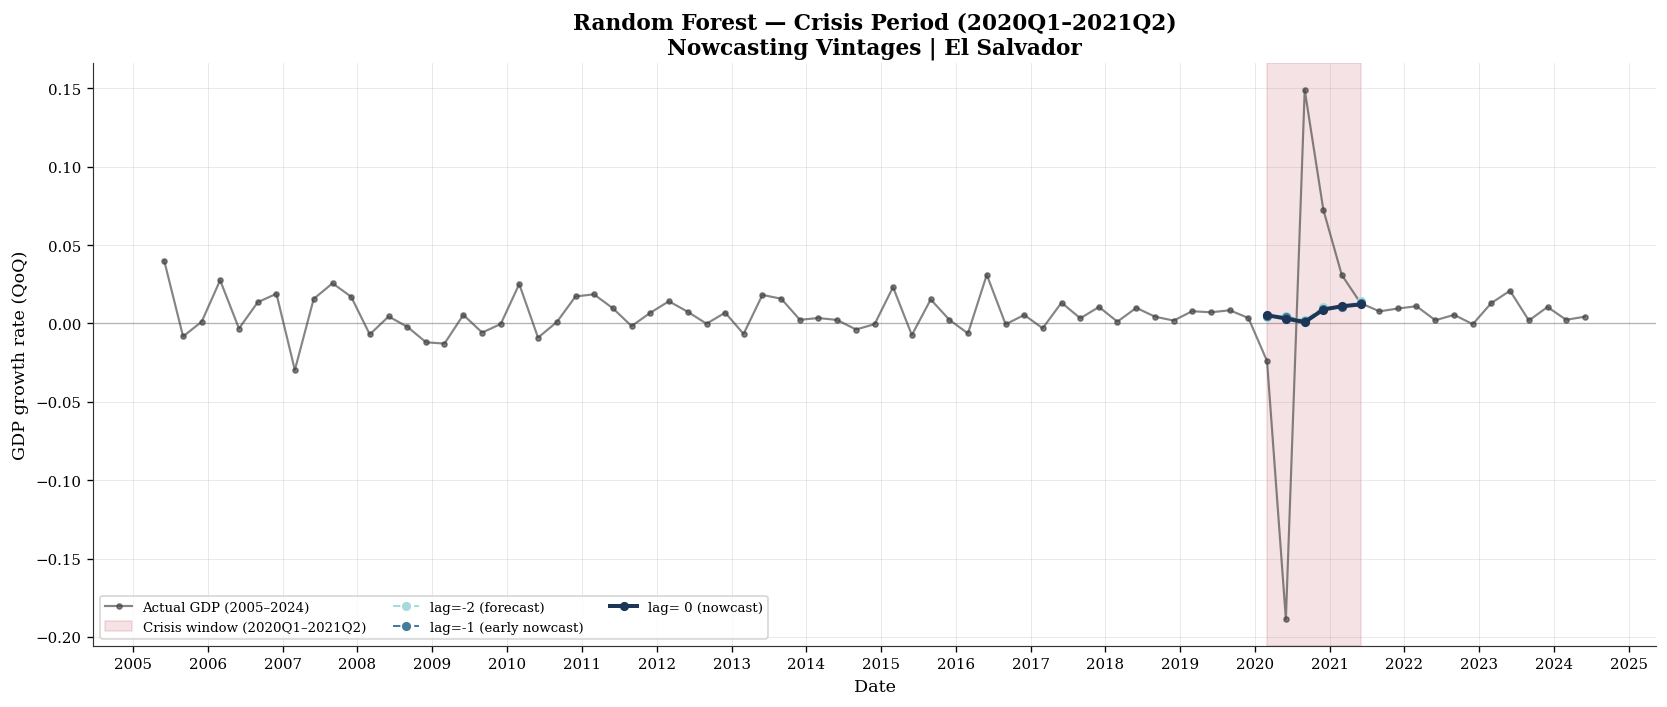

Saved: rf_plot_crisis.png


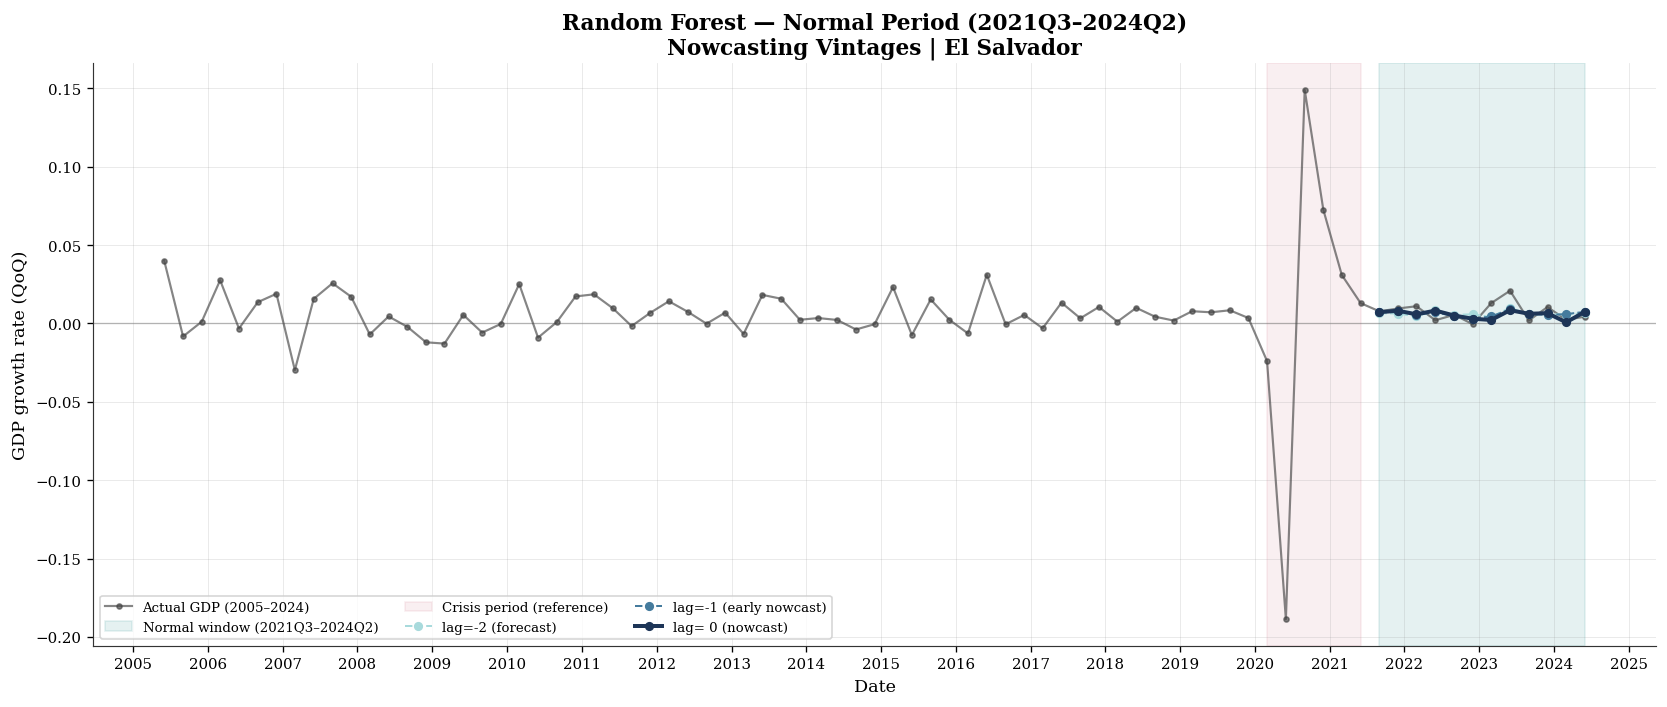

Saved: rf_plot_normal.png


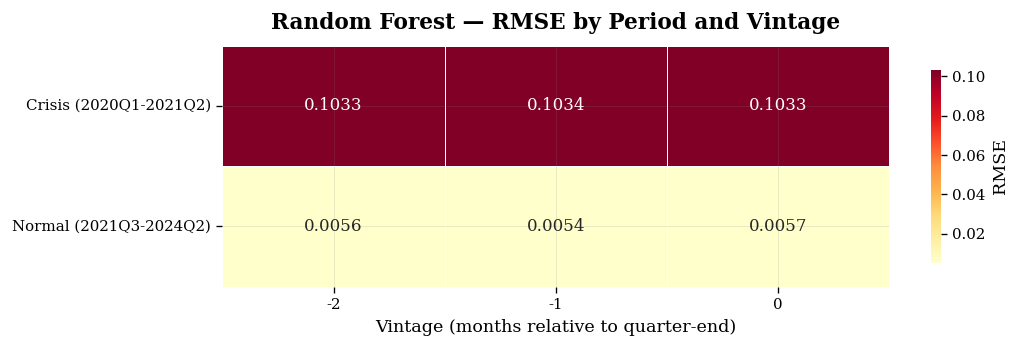

Saved: rf_plot_heatmap.png


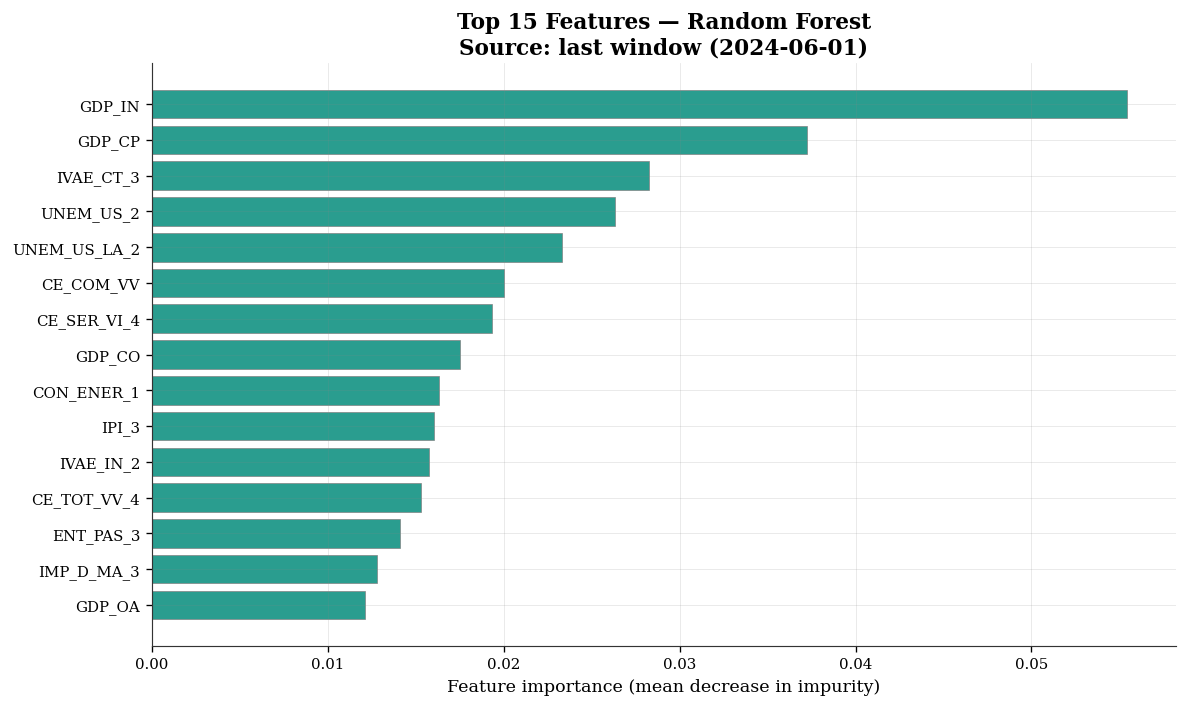

Saved: rf_plot_features.png


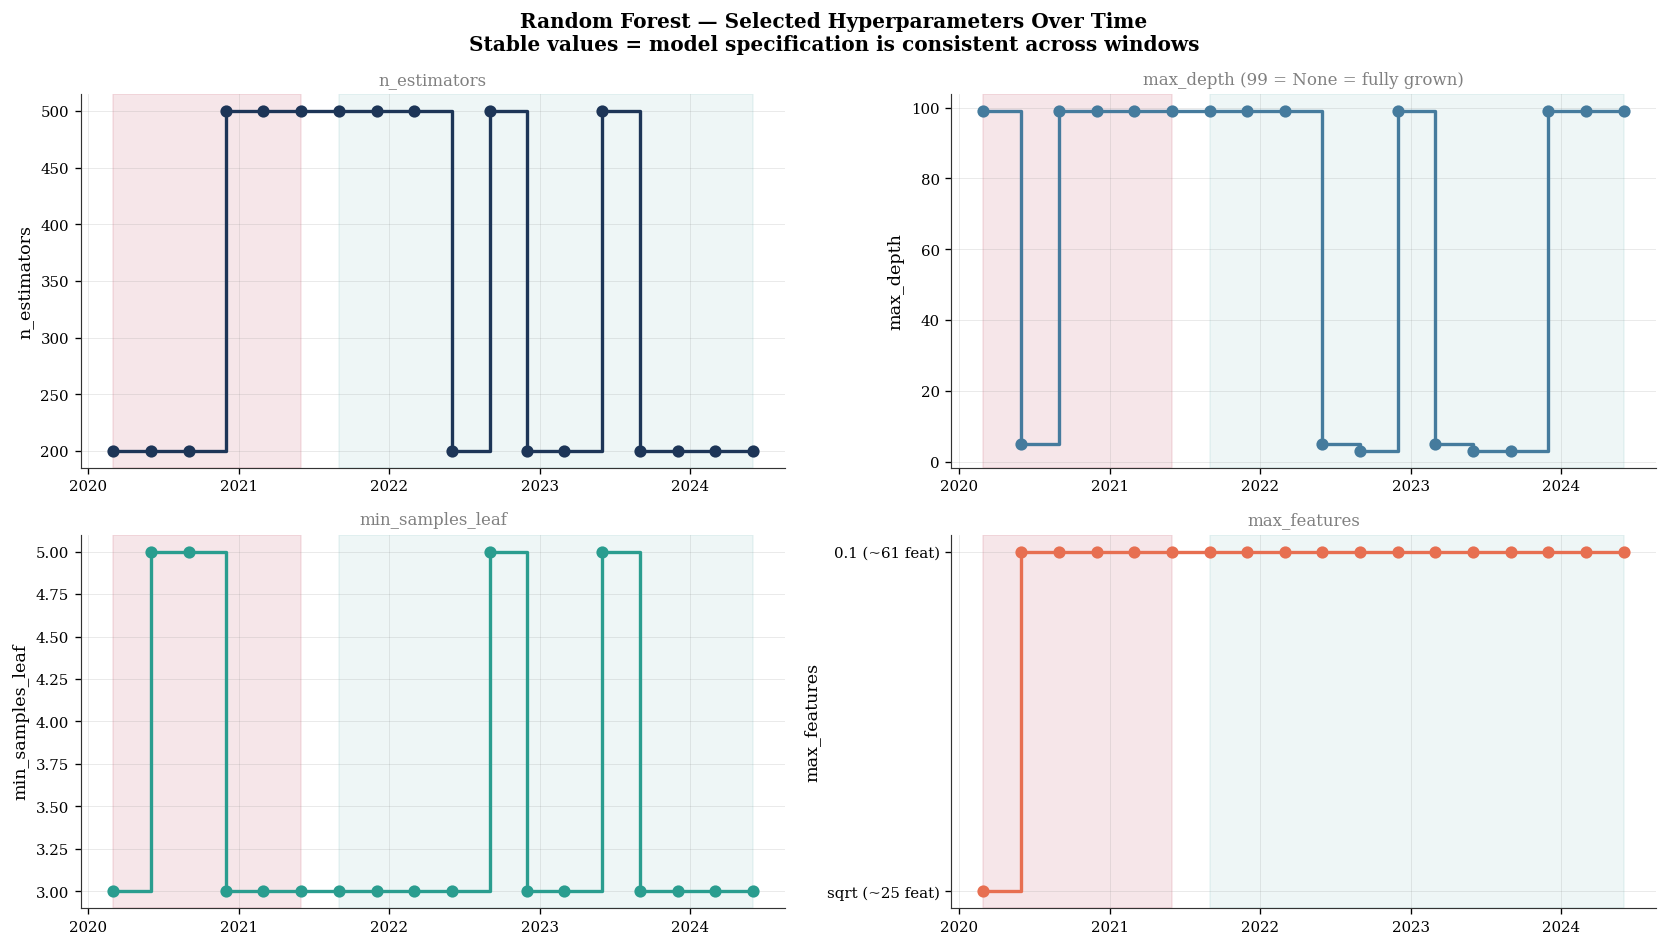

Saved: rf_plot_params.png

RANDOM FOREST NOWCASTING COMPLETE
Output : /Users/gabrielaaquino/Desktop/ESA-gdp-nowcasting/Models/results/randomforest


In [2]:
# =============================================================================
# RandomForest.py
# Random Forest nowcasting pipeline for El Salvador GDP.
# Hyperparameters selected via fixed holdout (last 8 quarters of training),
# identical protocol to Ridge, Lasso, and XGBoost for direct comparability.
#
# Primary benchmark is ARMA (see ARMA.ipynb). Cross-model comparison is
# done in a separate comparison script that loads all per-model CSVs.
#
# Author : Gabriela Aquino
# =============================================================================
#
# WHY RANDOM FOREST DIFFERS FROM XGBOOST
# ---------------------------------------
# Both are tree ensembles, but:
#
#   XGBoost       : BOOSTING — trees built sequentially, each correcting
#                   the errors of the previous. Strong learners, prone to
#                   overfit without tuning.
#
#   Random Forest : BAGGING — trees built independently on random subsamples
#                   of rows AND columns. Averaging reduces variance naturally.
#                   More stable and requires less hyperparameter tuning.
#
# For small samples (n~60), RF is often more stable than XGBoost because:
#   - Row subsampling (bootstrap) naturally regularises the model
#   - Column subsampling (max_features) reduces correlation between trees
#   - No sequential dependency — one unstable tree does not corrupt others
#
# NOTE ON IMPUTATION:
# Unlike XGBoost, sklearn's RandomForestRegressor does NOT handle NaN natively.
# Mean-fill is therefore required (not a methodological choice as in XGBoost).
# =============================================================================
#
# TUNABLE PARAMETERS (safe to modify — see Section 1):
#   N_LAGS_FEATURES     : monthly lags per predictor (baseline = 4)
#   RF_PARAM_GRID       : hyperparameter grid
#   N_HOLDOUT_QUARTERS  : size of fixed holdout for tuning (default 8)
#
# SHARED CONFIG (do not modify — comes from nowcast_utils.py):
#   LAGS, TRAIN_START, TEST_START, TEST_END,
#   CRISIS_START/END, NORMAL_START/END, etc.
# =============================================================================

import sys
import warnings
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor

# Selective warning filters.
# We WANT to see sklearn warnings (convergence, feature names) and warnings
# from gen_lagged_data. Silence only noisy FutureWarning and UserWarning
# from third parties.
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# =============================================================================
# 0. PATHS AND SHARED-CONFIG IMPORT
# =============================================================================
BASE_DIR  = Path.home() / "Desktop" / "ESA-gdp-nowcasting"
DATA_DIR  = BASE_DIR / "Data"
MODEL_DIR = BASE_DIR / "Models"
OUT_DIR   = MODEL_DIR / "results" / "randomforest"
OUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(MODEL_DIR))

from nowcast_utils import (
    LAGS, TARGET_VARIABLE,
    TRAIN_START, TEST_START, TEST_END,
    CRISIS_START, CRISIS_END,
    NORMAL_START, NORMAL_END,
    RANDOM_SEED,
    gen_lagged_data, flatten_data, mean_fill_dataset,
    classify_crisis_periods,
    rmse, mae,
)

PATH_DATA = DATA_DIR / "data_tf.csv"
PATH_META = DATA_DIR / "meta_data_v2.csv"
for p in [PATH_DATA, PATH_META]:
    if not p.exists():
        raise FileNotFoundError(f"\n  File not found: {p}")

# =============================================================================
# 1. TUNABLE PARAMETERS (Random Forest-specific)
# =============================================================================
# Number of monthly lags per predictor. MUST match Ridge/Lasso/XGBoost.
N_LAGS_FEATURES: int = 4

# Fixed holdout: last N quarters of training used for hyperparameter selection.
# MUST match all other models.
N_HOLDOUT_QUARTERS: int = 8

# Random Forest hyperparameter grid.
# Kept deliberately small given n ~ 55-76 quarterly observations.
#
# n_estimators     : number of trees. More = lower variance, diminishing
#                    returns after ~300.
# max_depth        : None = fully grown. With small n, shallow trees (3-5)
#                    prevent memorising individual quarters.
# min_samples_leaf : minimum observations per leaf. Critical for small n:
#                    use >= 3 to avoid single-obs leaves.
# max_features     : fraction of features considered per split.
#                    "sqrt" = ~25 features from 610 (standard RF default).
#                    0.1   = ~61 features, more conservative.
RF_PARAM_GRID = {
    "n_estimators":      [200, 500],
    "max_depth":         [3, 5, None],
    "min_samples_leaf":  [3, 5],
    "max_features":      ["sqrt", 0.1],
}
RF_FIXED_PARAMS = {
    "random_state": RANDOM_SEED,
    "n_jobs":       -1,
}

np.random.seed(RANDOM_SEED)

# =============================================================================
# 2. LOAD DATA
# =============================================================================
print("Loading data...")
data     = pd.read_csv(PATH_DATA, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
metadata = pd.read_csv(PATH_META)

print(f"  Rows       : {data.shape[0]}")
print(f"  Columns    : {data.shape[1]}")
print(f"  Date range : {data['date'].min().date()} to {data['date'].max().date()}")
print(f"  GDP obs    : {data[TARGET_VARIABLE].notna().sum()} quarterly observations")

# Build list of all grid combinations
param_keys   = list(RF_PARAM_GRID.keys())
param_values = list(RF_PARAM_GRID.values())
all_combos   = list(itertools.product(*param_values))
print(f"  Param grid : {len(all_combos)} combinations")

test_dates = pd.date_range(TEST_START, TEST_END, freq="3MS").strftime("%Y-%m-%d").tolist()

# =============================================================================
# 3. ROLLING-ORIGIN EVALUATION
# =============================================================================
print("\nRunning rolling-origin Random Forest evaluation...")
print(f"  Train start     : {TRAIN_START}")
print(f"  Test window     : {TEST_START} to {TEST_END}")
print(f"  Vintages        : {LAGS}")
print(f"  Lag depth       : {N_LAGS_FEATURES} monthly lags per predictor")
print(f"  Param grid      : {len(all_combos)} combinations (exhaustive)")
print(f"  Param selection : fixed holdout ({N_HOLDOUT_QUARTERS} quarters)")
print(f"  Scaling         : not applied (trees are scale-invariant)")
print(f"  Imputation      : training-mean fill (required: sklearn RF")
print(f"                    does not handle NaN natively)\n")

pred_dict                    = {lag: [] for lag in LAGS}
dates_out                    = []
actuals_out                  = []
best_params_out              = []
feature_importance_by_window = []   # list of (date, df) for post-hoc selection
train_cutoff_last            = None

for nowcast_date in test_dates:

    # --- Actual GDP value ----------------------------------------------------
    nowcast_dt  = pd.to_datetime(nowcast_date)
    actual_rows = data.loc[
        (data["date"] == nowcast_dt) & (~pd.isna(data[TARGET_VARIABLE])),
        TARGET_VARIABLE
    ]
    if actual_rows.empty:
        print(f"  [{nowcast_date}] No actual GDP - skipping.")
        for lag in LAGS:
            pred_dict[lag].append(np.nan)
        dates_out.append(nowcast_date)
        actuals_out.append(np.nan)
        best_params_out.append(None)
        continue

    dates_out.append(nowcast_date)
    actuals_out.append(float(actual_rows.values[0]))

    # --- Training window -----------------------------------------------------
    train_cutoff      = (nowcast_dt - pd.DateOffset(months=3)).strftime("%Y-%m-%d")
    train_cutoff_last = train_cutoff

    train_raw = data.loc[
        (data["date"] >= TRAIN_START) & (data["date"] <= train_cutoff)
    ].copy()

    n_q = train_raw[TARGET_VARIABLE].notna().sum()

    # --- Build feature matrix ------------------------------------------------
    # Mean-fill with training means (required: sklearn RF does not handle NaN).
    # Then flatten to quarterly rows (months 3/6/9/12).
    train_filled = mean_fill_dataset(training=train_raw, test=train_raw)
    train_flat   = flatten_data(train_filled, TARGET_VARIABLE, N_LAGS_FEATURES)
    train_flat   = (
        train_flat
        .loc[train_flat["date"].dt.month.isin([3, 6, 9, 12])]
        .dropna(axis=0, how="any")
        .reset_index(drop=True)
    )

    if len(train_flat) < N_HOLDOUT_QUARTERS + 5:
        print(f"  [{nowcast_date}] Only {len(train_flat)} rows - skipping.")
        for lag in LAGS:
            pred_dict[lag].append(np.nan)
        best_params_out.append(None)
        continue

    X_train = train_flat.drop(columns=["date", TARGET_VARIABLE])
    y_train = train_flat[TARGET_VARIABLE]

    # --- Hyperparameter selection via fixed holdout --------------------------
    # Protocol identical to ridge, lasso, and xgboost scripts.
    # RF does NOT need feature scaling — trees split on rank order.
    X_inner = X_train.iloc[:-N_HOLDOUT_QUARTERS]
    y_inner = y_train.iloc[:-N_HOLDOUT_QUARTERS]
    X_hold  = X_train.iloc[-N_HOLDOUT_QUARTERS:]
    y_hold  = y_train.iloc[-N_HOLDOUT_QUARTERS:]

    # Grid search: find combination that minimises holdout RMSE
    best_params, best_rmse = None, np.inf
    for combo in all_combos:
        tunable = dict(zip(param_keys, combo))
        rf_cv = RandomForestRegressor(**RF_FIXED_PARAMS, **tunable)
        rf_cv.fit(X_inner, y_inner)
        val_rmse = rmse(y_hold, rf_cv.predict(X_hold))
        if val_rmse < best_rmse:
            best_rmse   = val_rmse
            best_params = tunable

    best_params_out.append(best_params)

    # --- Refit RF on full training with best params --------------------------
    final_rf = RandomForestRegressor(**RF_FIXED_PARAMS, **best_params)
    final_rf.fit(X_train, y_train)

    # Feature importance (mean impurity decrease across all trees)
    feature_importance_by_window.append((
        nowcast_date,
        pd.DataFrame({
            "feature":    X_train.columns,
            "importance": final_rf.feature_importances_,
        }).sort_values("importance", ascending=False)
    ))

    # --- Diagnostics print ---------------------------------------------------
    depth_str = str(best_params["max_depth"]) if best_params["max_depth"] is not None else "None"
    print(f"  [{nowcast_date}]  "
          f"n_est={best_params['n_estimators']}  "
          f"depth={depth_str}  "
          f"min_leaf={best_params['min_samples_leaf']}  "
          f"max_feat={best_params['max_features']}  "
          f"n_train={n_q}  features={X_train.shape[1]}")

    # --- Predict for each vintage -------------------------------------------
    for lag in LAGS:
        vintage_data = gen_lagged_data(metadata, data, nowcast_date, lag)
        vintage_data = mean_fill_dataset(training=train_raw, test=vintage_data)
        vintage_flat = flatten_data(vintage_data, TARGET_VARIABLE, N_LAGS_FEATURES)

        target_row = vintage_flat.loc[vintage_flat["date"] == nowcast_dt]
        if target_row.empty:
            pred_dict[lag].append(np.nan)
            continue

        X_test = (
            target_row
            .drop(columns=["date", TARGET_VARIABLE], errors="ignore")
            .reindex(columns=X_train.columns, fill_value=0.0)
        )

        pred_dict[lag].append(float(final_rf.predict(X_test)[0]))

# =============================================================================
# 4. PERFORMANCE METRICS
# =============================================================================
# Period labels come from nowcast_utils (single source of truth)
period_labels = classify_crisis_periods(dates_out).tolist()

# --- Full test period --------------------------------------------------------
full_rows = []
for lag in LAGS:
    full_rows.append({
        "Vintage": lag,
        "RMSE":    round(rmse(actuals_out, pred_dict[lag]), 6),
        "MAE":     round(mae(actuals_out,  pred_dict[lag]), 6),
        "n":       sum(1 for v in pred_dict[lag] if not np.isnan(v)),
    })
perf_full = pd.DataFrame(full_rows)

# --- Stratified: Crisis / Normal --------------------------------------------
strat_rows = []
for period, label in [
    ("crisis", "Crisis (2020Q1-2021Q2)"),
    ("normal", "Normal (2021Q3-2024Q2)"),
]:
    idx = [i for i, p in enumerate(period_labels) if p == period]
    y   = [actuals_out[i] for i in idx]
    for lag in LAGS:
        yhat = [pred_dict[lag][i] for i in idx]
        strat_rows.append({
            "Period":  label,
            "Vintage": lag,
            "n":       len([v for v in yhat if not np.isnan(v)]),
            "RMSE":    round(rmse(y, yhat), 6),
            "MAE":     round(mae(y,  yhat), 6),
        })
perf_strat = pd.DataFrame(strat_rows)

# --- Print results -----------------------------------------------------------
print("\n" + "=" * 64)
print("FULL TEST PERIOD — Random Forest")
print("=" * 64)
print(perf_full.to_string(index=False))

print("\n" + "=" * 64)
print("STRATIFIED — Crisis vs Normal")
print("=" * 64)
print(perf_strat.to_string(index=False))

print(f"\nBenchmark: compare against ARMA (see arma_benchmark.csv).")
print(f"Cross-model comparison is done in the dedicated comparison script.")

# =============================================================================
# 5. SAVE CSVs
# =============================================================================
# Save ALL tunable hyperparameters.
pred_table = pd.DataFrame({
    "date":        dates_out,
    "actual":      actuals_out,
    **{f"lag_{'-' if lag < 0 else '+'}{abs(lag)}": pred_dict[lag] for lag in LAGS},
    "period_type": period_labels,
})
for pk in param_keys:
    # Cast to str so None and "sqrt" coexist cleanly in the CSV.
    pred_table[f"best_{pk}"] = [
        str(p[pk]) if p is not None else None for p in best_params_out
    ]

pred_table.to_csv(OUT_DIR   / "rf_predictions.csv",            index=False)
perf_full.to_csv(OUT_DIR    / "rf_performance_full.csv",       index=False)
perf_strat.to_csv(OUT_DIR   / "rf_performance_stratified.csv", index=False)

# --- Feature importance: last pre-crisis window -----------------------------
# Same logic as Ridge/Lasso/XGBoost: avoid COVID-period instability.
crisis_start_dt = pd.to_datetime(CRISIS_START)
pre_crisis = [
    (d, df) for (d, df) in feature_importance_by_window
    if pd.to_datetime(d) < crisis_start_dt
]

if pre_crisis:
    chosen_date, chosen_df = pre_crisis[-1]
    feature_importance_source = f"last pre-crisis window ({chosen_date})"
elif feature_importance_by_window:
    chosen_date, chosen_df = feature_importance_by_window[-1]
    feature_importance_source = f"last window ({chosen_date})"
else:
    chosen_df = None
    feature_importance_source = "no window available"

if chosen_df is not None:
    chosen_df.to_csv(OUT_DIR / "rf_feature_importance.csv", index=False)
    print(f"\nFeature importance from: {feature_importance_source}")

print(f"\nCSVs saved to: {OUT_DIR}")

# =============================================================================
# 6. PLOTTING STYLE (matches ARMA/Lasso/Ridge/XGBoost for visual consistency)
# =============================================================================
STYLE = {
    "c_crisis":         "#B6213B",
    "c_normal":         "#2A8F93",
    "c_actual":         "#2E2E2E",
    "zero_line_colour": "#555555",
    "shade_crisis":     0.11,
    "shade_normal":     0.08,
}
plt.rcParams.update({
    "font.family":       "serif",
    "axes.titlesize":    13,
    "axes.labelsize":    10.5,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "axes.grid":         True,
    "grid.alpha":        0.20,
    "grid.color":        "#888888",
    "grid.linewidth":    0.5,
    "axes.edgecolor":    "#333333",
    "axes.linewidth":    0.7,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        120,
})

LAG_COLORS = {-2: "#a8dadc", -1: "#457b9d", 0: "#1d3557"}
LAG_LW     = {-2: 1.2, -1: 1.2, 0: 2.4}
LAG_LS     = {-2: "--", -1: "--", 0: "-"}
LAG_LABELS = {-2: "lag=-2 (forecast)",
              -1: "lag=-1 (early nowcast)",
               0: "lag= 0 (nowcast)"}


def _format_xaxis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))


def _shade_regimes(ax):
    ax.axvspan(pd.to_datetime(CRISIS_START), pd.to_datetime(CRISIS_END),
               alpha=STYLE["shade_crisis"], color=STYLE["c_crisis"],
               edgecolor="none", zorder=0)
    ax.axvspan(pd.to_datetime(NORMAL_START), pd.to_datetime(NORMAL_END),
               alpha=STYLE["shade_normal"], color=STYLE["c_normal"],
               edgecolor="none", zorder=0)


full_series = (
    data[["date", TARGET_VARIABLE]]
    .dropna(subset=[TARGET_VARIABLE])
    .sort_values("date")
    .reset_index(drop=True)
)

# =============================================================================
# 7. PLOT A — Crisis period (2020Q1–2021Q2)
# =============================================================================
crisis_rows = pred_table[pred_table["period_type"] == "crisis"].copy()
crisis_rows["date"] = pd.to_datetime(crisis_rows["date"])

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(full_series["date"], full_series[TARGET_VARIABLE],
        color="#444444", lw=1.3, marker="o", ms=3, alpha=0.65,
        label="Actual GDP (2005–2024)", zorder=3)
ax.axvspan(pd.to_datetime(CRISIS_START), pd.to_datetime(CRISIS_END),
           alpha=0.13, color=STYLE["c_crisis"], zorder=0,
           label="Crisis window (2020Q1–2021Q2)")
ax.axhline(0, color=STYLE["zero_line_colour"], lw=0.8, alpha=0.4, zorder=1)

for lag in LAGS:
    col = f"lag_{'-' if lag < 0 else '+'}{abs(lag)}"
    ax.plot(crisis_rows["date"], crisis_rows[col],
            color=LAG_COLORS[lag], lw=LAG_LW[lag], ls=LAG_LS[lag],
            marker="o", ms=4.5, label=LAG_LABELS[lag], zorder=5)

ax.set_xlabel("Date")
ax.set_ylabel("GDP growth rate (QoQ)")
ax.set_title("Random Forest — Crisis Period (2020Q1–2021Q2)\n"
             "Nowcasting Vintages | El Salvador",
             fontweight="bold")
ax.legend(fontsize=8, ncol=3, loc="lower left")
_format_xaxis(ax)
plt.tight_layout()
fig.savefig(OUT_DIR / "rf_plot_crisis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rf_plot_crisis.png")

# =============================================================================
# 8. PLOT B — Normal period (2021Q3–2024Q2)
# =============================================================================
normal_rows = pred_table[pred_table["period_type"] == "normal"].copy()
normal_rows["date"] = pd.to_datetime(normal_rows["date"])

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(full_series["date"], full_series[TARGET_VARIABLE],
        color="#444444", lw=1.3, marker="o", ms=3, alpha=0.65,
        label="Actual GDP (2005–2024)", zorder=3)
ax.axvspan(pd.to_datetime(NORMAL_START), pd.to_datetime(NORMAL_END),
           alpha=0.12, color=STYLE["c_normal"], zorder=0,
           label="Normal window (2021Q3–2024Q2)")
ax.axvspan(pd.to_datetime(CRISIS_START), pd.to_datetime(CRISIS_END),
           alpha=0.07, color=STYLE["c_crisis"], zorder=0,
           label="Crisis period (reference)")
ax.axhline(0, color=STYLE["zero_line_colour"], lw=0.8, alpha=0.4, zorder=1)

for lag in LAGS:
    col = f"lag_{'-' if lag < 0 else '+'}{abs(lag)}"
    ax.plot(normal_rows["date"], normal_rows[col],
            color=LAG_COLORS[lag], lw=LAG_LW[lag], ls=LAG_LS[lag],
            marker="o", ms=4.5, label=LAG_LABELS[lag], zorder=5)

ax.set_xlabel("Date")
ax.set_ylabel("GDP growth rate (QoQ)")
ax.set_title("Random Forest — Normal Period (2021Q3–2024Q2)\n"
             "Nowcasting Vintages | El Salvador",
             fontweight="bold")
ax.legend(fontsize=8, ncol=3, loc="lower left")
_format_xaxis(ax)
plt.tight_layout()
fig.savefig(OUT_DIR / "rf_plot_normal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rf_plot_normal.png")

# =============================================================================
# 9. PLOT C — RMSE heatmap
# =============================================================================
pivot = perf_strat.pivot(index="Period", columns="Vintage", values="RMSE")
fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.6, ax=ax, cbar_kws={"label": "RMSE", "shrink": 0.8})
ax.set_title("Random Forest — RMSE by Period and Vintage",
             fontweight="bold", pad=10)
ax.set_xlabel("Vintage (months relative to quarter-end)")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(OUT_DIR / "rf_plot_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rf_plot_heatmap.png")

# =============================================================================
# 10. PLOT D — Feature importance (top 15)
# =============================================================================
# RF feature importance = mean decrease in impurity (MDI) across all trees.
# Unlike XGBoost (gain), MDI can overrate high-cardinality features.
# Still useful for directional interpretation.
if chosen_df is not None:
    top_n     = 15
    top_feats = chosen_df.head(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_feats["feature"][::-1],
            top_feats["importance"][::-1],
            color="#2a9d8f", edgecolor="gray", linewidth=0.4)
    ax.set_xlabel("Feature importance (mean decrease in impurity)")
    ax.set_title(f"Top {top_n} Features — Random Forest\n"
                 f"Source: {feature_importance_source}",
                 fontweight="bold")
    plt.tight_layout()
    fig.savefig(OUT_DIR / "rf_plot_features.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: rf_plot_features.png")

# =============================================================================
# 11. PLOT E — Selected hyperparameters over time
# =============================================================================
valid = [(d, p) for d, p in zip(dates_out, best_params_out) if p is not None]
if valid:
    v_dates  = pd.to_datetime([x[0] for x in valid])
    v_params = [x[1] for x in valid]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle("Random Forest — Selected Hyperparameters Over Time\n"
                 "Stable values = model specification is consistent across windows",
                 fontweight="bold")

    # n_estimators
    ax = axes[0][0]
    _shade_regimes(ax)
    vals = [p["n_estimators"] for p in v_params]
    ax.step(v_dates, vals, color="#1d3557", lw=2, where="post")
    ax.scatter(v_dates, vals, color="#1d3557", s=40, zorder=5)
    ax.set_title("n_estimators", fontsize=10, color="gray")
    ax.set_ylabel("n_estimators")
    _format_xaxis(ax)

    # max_depth (None encoded as 99 for plotting)
    ax = axes[0][1]
    _shade_regimes(ax)
    vals = [p["max_depth"] if p["max_depth"] is not None else 99
            for p in v_params]
    ax.step(v_dates, vals, color="#457b9d", lw=2, where="post")
    ax.scatter(v_dates, vals, color="#457b9d", s=40, zorder=5)
    ax.set_title("max_depth (99 = None = fully grown)",
                 fontsize=10, color="gray")
    ax.set_ylabel("max_depth")
    _format_xaxis(ax)

    # min_samples_leaf
    ax = axes[1][0]
    _shade_regimes(ax)
    vals = [p["min_samples_leaf"] for p in v_params]
    ax.step(v_dates, vals, color="#2a9d8f", lw=2, where="post")
    ax.scatter(v_dates, vals, color="#2a9d8f", s=40, zorder=5)
    ax.set_title("min_samples_leaf", fontsize=10, color="gray")
    ax.set_ylabel("min_samples_leaf")
    _format_xaxis(ax)

    # max_features
    ax = axes[1][1]
    _shade_regimes(ax)
    feat_map = {"sqrt": 0, 0.1: 1}
    vals = [feat_map.get(p["max_features"], p["max_features"])
            for p in v_params]
    ax.step(v_dates, vals, color="#e76f51", lw=2, where="post")
    ax.scatter(v_dates, vals, color="#e76f51", s=40, zorder=5)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["sqrt (~25 feat)", "0.1 (~61 feat)"])
    ax.set_title("max_features", fontsize=10, color="gray")
    ax.set_ylabel("max_features")
    _format_xaxis(ax)

    plt.tight_layout()
    fig.savefig(OUT_DIR / "rf_plot_params.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: rf_plot_params.png")

# =============================================================================
# DONE
# =============================================================================
print("\n" + "=" * 64)
print("RANDOM FOREST NOWCASTING COMPLETE")
print("=" * 64)
print(f"Output : {OUT_DIR}")